In [4]:
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [5]:
# ============================================================
# LOAD BEST CONFIG
# ============================================================

import json

# Open the file and parse its contents
with open('physicsnet_bho/best_config.json', 'r') as file:
    best_configuration = json.load(file)
best_configuration

{'depth': 3,
 'width': 256,
 'activation': 'silu',
 'lr': 0.00011487565177002337,
 'w_ic': 10,
 'rho_bias': 2,
 'fo_bias': 1}

In [6]:
# ============================================================
# CONFIG
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# Network 2 architecture (must match the main script's PhysicsNet)
N2_DEPTH = best_configuration["depth"]
N2_WIDTH = best_configuration["width"]
N2_ACT = best_configuration["activation"]

# Pre-training
EPOCHS = 10000
LR = best_configuration["lr"]
N_COLLOCATION = 4000        # interior collocation points per step
N_IC = 2000                 # initial-condition points per step
FO_MAX = 1.5                # train u on Fo in [0, FO_MAX]
GRAD_CLIP = 1.0
 
# IC is weighted heavily: with no data term to compete, a large IC weight
# reliably blocks the trivial u==0 solution (which satisfies the PDE).
W_PDE = 1.0
W_IC = best_configuration["w_ic"]


rho_bias = best_configuration["rho_bias"]
fo_bias = best_configuration["fo_bias"]
 
SEED = 0

In [7]:
# ============================================================
# NETWORK (must match PhysicsNet in the main script)
# ============================================================
def get_activation(name):
    return {"tanh": nn.Tanh(), "silu": nn.SiLU(), "gelu": nn.GELU()}[name.lower()]
 
 
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, depth, width, activation):
        super().__init__()
        layers = [nn.Linear(in_dim, width), get_activation(activation)]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), get_activation(activation)]
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)
 
    def forward(self, x):
        return self.net(x)
 
 
class PhysicsNet(nn.Module):
    """Network 2: (rho, Fo) -> u(rho, Fo), hard BC u=0 at rho=1 via ansatz."""
    def __init__(self, depth=N2_DEPTH, width=N2_WIDTH, activation=N2_ACT):
        super().__init__()
        self.mlp = MLP(2, 1, depth, width, activation)
 
    def forward(self, rho, Fo):
        x = torch.cat([rho**2, Fo], dim=1)
        raw = self.mlp(x)
        return (1.0 - rho**2) * raw          # hard BC: u(rho=1) = 0

In [8]:
# ============================================================
# COLLOCATION SAMPLING (inline, no external dependency)
# ============================================================
def _exp_warp(u, strength):
    if strength <= 1e-8:
        return u
    s = torch.tensor(strength, dtype=u.dtype, device=u.device)
    return (torch.exp(strength * u) - 1.0) / torch.expm1(s)


def sample_collocation(n, fo_max, device, rho_bias=2.0, fo_bias=2.0):
    u_rho = torch.rand(n, 1, device=device)
    u_fo  = torch.rand(n, 1, device=device)
    Fo  = _exp_warp(u_fo,  fo_bias) * fo_max
    rho = 1.0 - _exp_warp(u_rho, rho_bias)
    return rho.requires_grad_(True), Fo.requires_grad_(True)


# ============================================================
# LOSSES
# ============================================================
# from collocation_sampling import sample_collocation

def pde_residual(net, n_colloc=N_COLLOCATION, fo_max=FO_MAX):
    """Mean squared residual of du/dFo - d2u/drho2 - (2/rho) du/drho."""
    device = next(net.parameters()).device
 
    # rho = torch.rand(n_colloc, 1, device=device, requires_grad=True)
    # Fo = (torch.rand(n_colloc, 1, device=device) * fo_max).requires_grad_(True)

    rho, Fo = sample_collocation(n_colloc, fo_max, next(net.parameters()).device,
                                 rho_bias=rho_bias, fo_bias=fo_bias)
    
    u = net(rho, Fo)
 
    du_dFo = torch.autograd.grad(u, Fo, torch.ones_like(u), create_graph=True)[0]
    du_drho = torch.autograd.grad(u, rho, torch.ones_like(u), create_graph=True)[0]
    d2u_drho2 = torch.autograd.grad(
        du_drho, rho, torch.ones_like(du_drho), create_graph=True
    )[0]
 
    laplacian = d2u_drho2 + (2.0 / (rho + 1e-6)) * du_drho
    residual = du_dFo - laplacian
    return torch.mean(residual ** 2)
 
 
def ic_loss(net, n_points=N_IC):
    """Initial-condition loss: enforce u(rho, Fo=0) = 1."""
    device = next(net.parameters()).device
    rho = torch.rand(n_points, 1, device=device)
    Fo = torch.zeros(n_points, 1, device=device)
    u = net(rho, Fo)
    return torch.mean((u - 1.0) ** 2)


In [9]:
# ============================================================
# VERIFICATION against Crank's analytical series
# ============================================================
def crank_u(rho, Fo, n_terms=170):
    """
    Analytical u(rho, Fo) from Crank's series for a sphere.
 
    u(rho, Fo) = (2/(pi*rho)) * sum_{n=1}^N [ ((-1)^(n+1))/n
                  * sin(n*pi*rho) * exp(-n^2 pi^2 Fo) ]
 
    Used only to check the pre-trained network's accuracy. Not used in
    training. rho, Fo are numpy arrays of equal shape.
    """
    rho = np.asarray(rho, dtype=float)
    Fo = np.asarray(Fo, dtype=float)
    out = np.zeros_like(rho)
    for n in range(1, n_terms + 1):
        out += ((-1.0) ** (n + 1) / n) * np.sin(n * np.pi * rho) \
               * np.exp(-(n ** 2) * (np.pi ** 2) * Fo)
    # Multiply by 2/(pi*rho); handle rho -> 0 by the limit u(0,Fo).
    with np.errstate(divide="ignore", invalid="ignore"):
        u = (2.0 / (np.pi * rho)) * out
    # At rho = 0 the series limit: u(0,Fo) = 2 * sum (-1)^(n+1) exp(...)
    limit0 = np.zeros_like(rho)
    for n in range(1, n_terms + 1):
        limit0 += ((-1.0) ** (n + 1)) * np.exp(-(n ** 2) * (np.pi ** 2) * Fo)
    limit0 = 2.0 * limit0
    u = np.where(rho < 1e-9, limit0, u)
    return np.clip(u, 0.0, 1.0)


def verify(net):
    """Compare the trained network to Crank's analytical solution."""
    net.eval()
    # Grid avoiding Fo=0 (series + network both special there) and rho=0,1 edges.
    rho_vals = np.linspace(0.02, 0.98, 40)
    fo_vals = np.linspace(0.02, FO_MAX, 40)
    RR, FF = np.meshgrid(rho_vals, fo_vals)
 
    u_true = crank_u(RR.ravel(), FF.ravel())
 
    with torch.no_grad():
        rho_t = torch.tensor(RR.ravel(), dtype=torch.float32,
                             device=DEVICE).view(-1, 1)
        fo_t = torch.tensor(FF.ravel(), dtype=torch.float32,
                            device=DEVICE).view(-1, 1)
        u_net = net(rho_t, fo_t).cpu().numpy().ravel()
 
    abs_err = np.abs(u_net - u_true)
    print(f"  vs Crank analytical:  mean |err| = {abs_err.mean():.4e}, "
          f"max |err| = {abs_err.max():.4e}")
    return abs_err.mean(), abs_err.max()

In [10]:
# ============================================================
# TRAIN
# ============================================================
def main():
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    print(f"Device: {DEVICE}")
 
    net = PhysicsNet().to(DEVICE)
    n_params = sum(p.numel() for p in net.parameters())
    print(f"Network 2: {n_params:,} params")
 
    optimizer = torch.optim.Adam(net.parameters(), lr=LR)
    print(f"Pre-training {EPOCHS} epochs | W_PDE={W_PDE}, W_IC={W_IC}")
    print("-" * 70)
 
    for epoch in range(EPOCHS):
        net.train()
        optimizer.zero_grad()
 
        loss_pde = pde_residual(net)
        loss_ic = ic_loss(net)
        loss = W_PDE * loss_pde + W_IC * loss_ic
 
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
        optimizer.step()
 
        if epoch % 250 == 0 or epoch == EPOCHS - 1:
            print(
                f"epoch {epoch:5d} | "
                f"pde {loss_pde.item():.3e} | "
                f"ic {loss_ic.item():.3e}"
            )
 
    print("-" * 70)
    print("Pre-training done. Verifying against analytical solution:")
    verify(net)
    
    return net

In [11]:
net = main()

Device: cuda
Network 2: 132,609 params
Pre-training 10000 epochs | W_PDE=1.0, W_IC=10
----------------------------------------------------------------------
epoch     0 | pde 2.131e-01 | ic 1.103e+00
epoch   250 | pde 6.441e-01 | ic 2.050e-01
epoch   500 | pde 1.592e-01 | ic 1.783e-01
epoch   750 | pde 1.948e-01 | ic 1.551e-01
epoch  1000 | pde 2.880e-01 | ic 1.238e-01
epoch  1250 | pde 2.015e-01 | ic 1.046e-01
epoch  1500 | pde 1.067e-01 | ic 8.136e-02
epoch  1750 | pde 6.425e-02 | ic 8.428e-02
epoch  2000 | pde 8.952e-02 | ic 7.219e-02
epoch  2250 | pde 5.698e-02 | ic 7.038e-02
epoch  2500 | pde 9.853e-02 | ic 6.617e-02
epoch  2750 | pde 9.383e-02 | ic 6.754e-02
epoch  3000 | pde 7.796e-02 | ic 6.015e-02
epoch  3250 | pde 9.454e-02 | ic 5.268e-02
epoch  3500 | pde 6.592e-02 | ic 5.339e-02
epoch  3750 | pde 3.463e-02 | ic 5.337e-02
epoch  4000 | pde 1.070e-01 | ic 5.080e-02
epoch  4250 | pde 4.800e-02 | ic 4.973e-02
epoch  4500 | pde 8.845e-02 | ic 4.846e-02
epoch  4750 | pde 6.601e-0

# Make u(rho, Fo) at different Fo values

In [12]:
rho_vals = np.linspace(0, 1, 100)
fo_vals = np.array([0.01, 0.015, 0.03, 0.15, 0.3, 0.7])

RR, FF = np.meshgrid(rho_vals, fo_vals)
 
u_true = crank_u(RR.ravel(), FF.ravel())
 
with torch.no_grad():
    rho_t = torch.tensor(RR.ravel(), dtype=torch.float32,
                         device=DEVICE).view(-1, 1)
    fo_t = torch.tensor(FF.ravel(), dtype=torch.float32,
                        device=DEVICE).view(-1, 1)
    u_net = net(rho_t, fo_t).cpu().numpy().ravel()


u_net_2D = u_net.reshape(len(fo_vals), 100)
u_true_2D = u_true.reshape(len(fo_vals), 100)

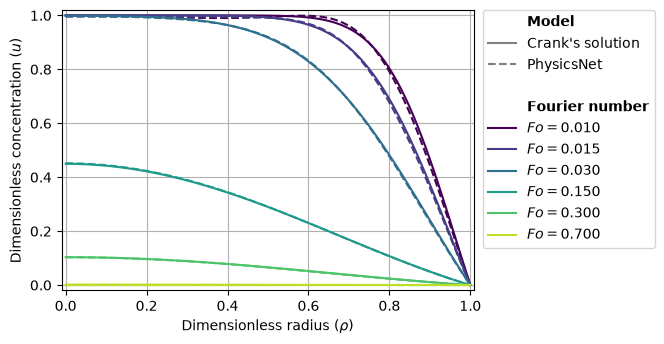

In [13]:
# ---- Figure 2: PhysicsNet vs analytical concentration field ----
fig, ax = plt.subplots(figsize=(6.5, 3.4))      # full text width (US Letter, 1" margins)

# Color-code Fourier numbers; cap viridis short of its lightest yellow for contrast
colors = plt.cm.viridis(np.linspace(0.0, 0.9, len(fo_vals)))

for f in range(len(fo_vals)):
    ax.plot(rho_vals, u_true_2D[f, :], color=colors[f], linestyle='-')    # analytical (solid)
    ax.plot(rho_vals, u_net_2D[f, :],  color=colors[f], linestyle='--')   # PhysicsNet (dashed)

# ---- Unified legend: model block + Fourier-number block ----
style_handles = [
    Line2D([0], [0], color='gray', linestyle='-',  label="Crank's solution"),
    Line2D([0], [0], color='gray', linestyle='--', label='PhysicsNet'),
]
color_handles = [
    Line2D([0], [0], color=colors[f], linestyle='-', label=fr"$Fo = {fo_vals[f]:.3f}$")
    for f in range(len(fo_vals))
]
header_model = Line2D([], [], color='none', label=r'$\bf{Model}$')
header_fo    = Line2D([], [], color='none', label=r'$\bf{Fourier\ number}$')
spacer       = Line2D([], [], color='none', label=' ')
all_handles  = [header_model, *style_handles, spacer, header_fo, *color_handles]

leg = ax.legend(handles=all_handles, loc='upper left',
                bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

# ---- Axes ----
ax.set_xlabel(r"Dimensionless radius ($\rho$)")
ax.set_ylabel(r"Dimensionless concentration ($u$)")     # was "Temperature" — fixed
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.02, 1.02)
ax.grid(True)                                           # light dotted grid from rcParams

# Reserve right margin for the legend so the SAVED width stays exactly 6.5 in
fig.subplots_adjust(left=0.085, right=0.72, top=0.96, bottom=0.135)

fig.savefig("../plots/fig2_physicsnet_field.pdf")           # vector — preferred for submission
fig.savefig("../plots/fig2_physicsnet_field.png", dpi=600)  # raster backup
plt.show()

# Make release profile and compare with Crank's 

In [14]:
def integrate_release(net2, Fo, rho_grid):
    """
    Compute fractional release for a batch of Fo values.
 
    Fo       : (B,)
    rho_grid : (n_rho,)
    Returns release : (B,)
    """
    B    = Fo.shape[0]
    n_rho = rho_grid.shape[0]
 
    Fo_exp  = Fo.view(B, 1).expand(B, n_rho).reshape(-1, 1)   # (B*n_rho, 1)
    rho_exp = rho_grid.view(1, n_rho).expand(B, n_rho).reshape(-1, 1)
 
    u   = net2(rho_exp, Fo_exp).view(B, n_rho)                # (B, n_rho)
    M_t = torch.trapz(u * rho_grid**2, rho_grid, dim=1)       # (B,)
 
    return torch.clamp(1.0 - 3.0 * M_t, min=0.0, max=1.0)    # (B,)


def crank_release_fo(Fo, n_terms=50):
    """
    Fractional release from a sphere as a function of Fourier number.

    Uses the Crank series solution for diffusion from a sphere:
        M/M_inf = 1 - (6/π²) Σ_{n=1}^{N} exp(-n²π²·Fo) / n²

    Parameters
    ----------
    Fo : array_like
        Fourier number (dimensionless time), Fo = D·t / R².
        Must be non-negative.
    n_terms : int
        Number of series terms. Default 50.

    Returns
    -------
    M_frac : ndarray
        Fractional cumulative release, clipped to [0, 1].
    """
    Fo = np.asarray(Fo, dtype=float)
    if np.any(Fo < 0):
        raise ValueError("Fourier number must be non-negative.")

    n = np.arange(1, n_terms + 1).reshape(-1, 1)  # (n_terms, 1)
    Fo_row = Fo.reshape(1, -1)                      # (1, len(Fo))

    series_sum = np.sum(np.exp(-(n**2) * (np.pi**2) * Fo_row) / n**2, axis=0)

    M_frac = 1.0 - (6.0 / np.pi**2) * series_sum
    return np.clip(M_frac, 0.0, 1.0)

In [15]:
N_RHO_INTEGRATION = 100
rho_grid = torch.linspace(0, 1, N_RHO_INTEGRATION, device=DEVICE)
Fo_grid = torch.linspace(0, 1, 1000, device=DEVICE)

release = integrate_release(net, Fo_grid, rho_grid)
crank_release_fo = crank_release_fo(Fo_grid.detach().cpu().numpy(), n_terms=50)

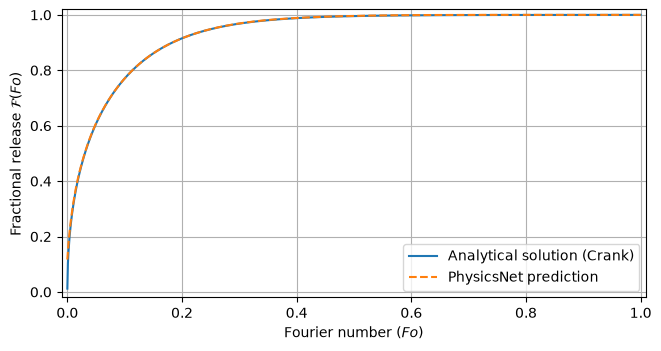

In [16]:
# ---- Figure 3: PhysicsNet fractional release vs analytical ----
fo_numpy     = Fo_grid.detach().cpu().numpy().ravel()
release_net  = release.detach().cpu().numpy().ravel()
release_true = crank_release_fo.ravel()

fig, ax = plt.subplots(figsize=(6.5, 3.4), constrained_layout=True)

ax.plot(fo_numpy, release_true, color='#1f77b4', linestyle='-',
        label="Analytical solution (Crank)")          # truth = solid
ax.plot(fo_numpy, release_net,  color='#ff7f0e', linestyle='--',
        label="PhysicsNet prediction")                # prediction = dashed

ax.set_xlabel(r"Fourier number ($Fo$)")
ax.set_ylabel(r"Fractional release $\mathcal{F}(Fo)$")
ax.set_xlim(-0.01, fo_numpy.max() + 0.01)
ax.set_ylim(-0.02, 1.02)
ax.grid(True)

ax.legend(loc='lower right')

fig.savefig("../plots/fig3_physicsnet_release.pdf")
fig.savefig("../plots/fig3_physicsnet_release.png", dpi=600)
plt.show()